## Support Vector Machines (SVM) - Intro and SVM for Regression

Support Vector Machines are the type of supervised learning algorithms used for regression, classification and detecting outliers. SVMs are remarkably one of the powerful models in classical machine learning suited for handling complex and high dimensional datasets.

With SVM supporting different kernels (linear, polynomial, Radial Basis Function(rbf), and sigmoid), SVM can tackle different kinds of datasets, both linear and non linear.

While the maths behind the SVMs are beyond the scope of this notebook, here is the idea behind SVMs:

*The way SVM works can be compared to a street with a boundary line. During SVM training, SMV draws the large margin or decision boundary between classes based on the importance of each training data point. The training data points that are inside the decision boundary are called support vectors and hence the name.*
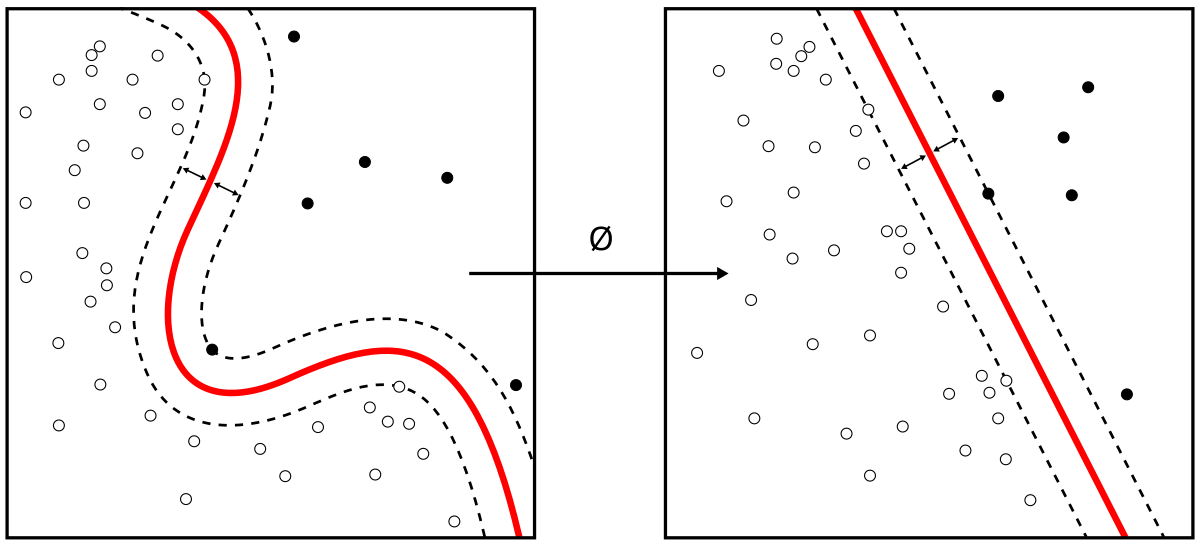

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import urllib.request
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
cal_data=pd.read_csv('/workspaces/learn-ML/End-to-End-ML/kaggle_datasets/housing.csv')
cal_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
len(cal_data)

20640

### EDA

In [5]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(cal_data, test_size=0.1,random_state=20)

print('The size of training data is: {} \nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 18576 
The size of testing data is: 2064


In [6]:
train_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
longitude,18576.0,-119.567530,2.000581,-124.3500,-121.7900,-118.4900,-118.010000,-114.4900
latitude,18576.0,35.630217,2.133260,32.5400,33.9300,34.2600,37.710000,41.9500
housing_median_age,18576.0,28.661068,12.604039,1.0000,18.0000,29.0000,37.000000,52.0000
total_rooms,18576.0,2631.567453,2169.467450,2.0000,1445.0000,2127.0000,3149.000000,39320.0000
total_bedrooms,18390.0,537.344698,417.672864,1.0000,295.0000,435.0000,648.000000,6445.0000
population,18576.0,1422.408376,1105.486111,3.0000,785.7500,1166.0000,1725.000000,28566.0000
households,18576.0,499.277078,379.473497,1.0000,279.0000,410.0000,606.000000,6082.0000
median_income,18576.0,3.870053,1.900225,0.4999,2.5643,3.5341,4.742725,15.0001
median_house_value,18576.0,206881.011305,115237.605962,14999.0000,120000.0000,179800.0000,264700.000000,500001.0000


In [7]:
train_data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        186
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
train_data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8231
INLAND        5896
NEAR OCEAN    2384
NEAR BAY      2061
ISLAND           4
Name: count, dtype: int64

<Axes: xlabel='ocean_proximity', ylabel='count'>

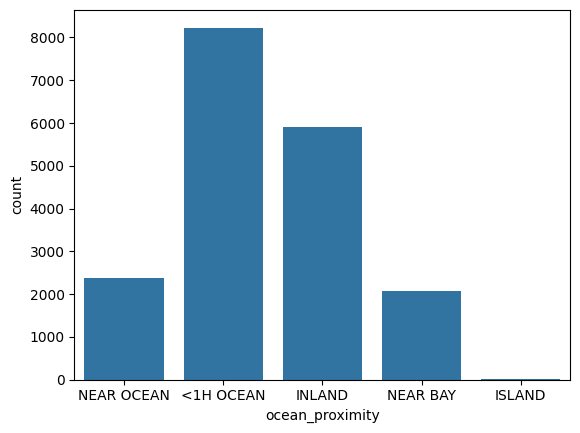

In [9]:
sns.countplot(data=train_data, x='ocean_proximity')

Total bedroom is the only feature having missing values. Here is its distribution.

<Axes: ylabel='Frequency'>

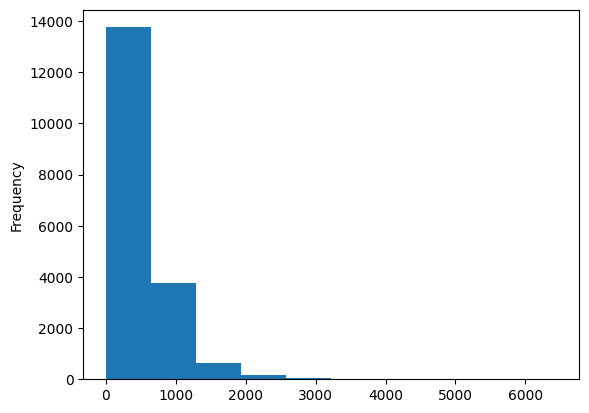

In [10]:
train_data['total_bedrooms'].plot(kind='hist')

<Axes: xlabel='longitude', ylabel='latitude'>

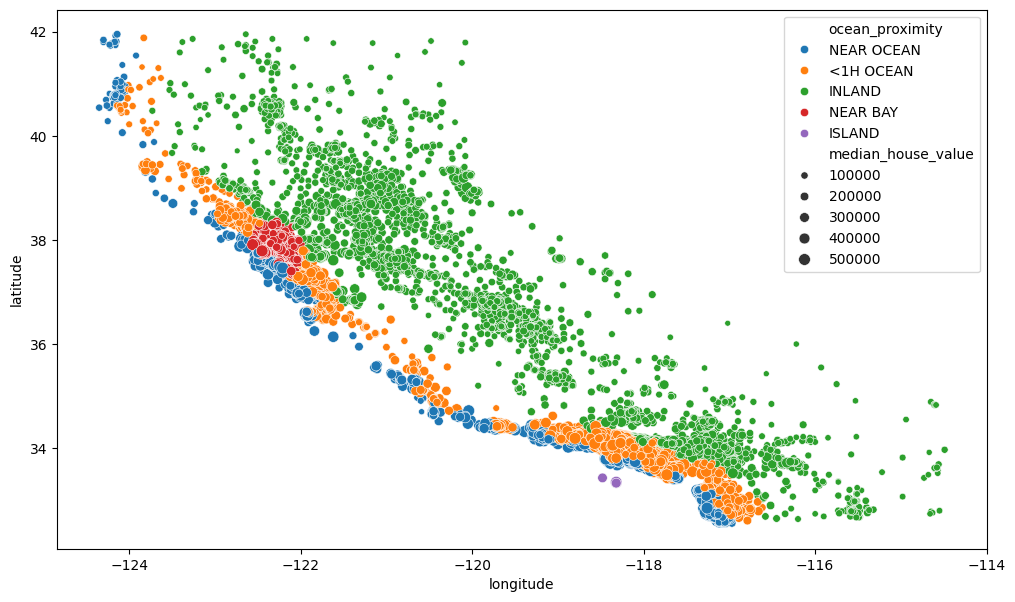

In [11]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=train_data, x='longitude', y='latitude', hue='ocean_proximity',size='median_house_value')

## Handling Missing values

To Do - 
1. Handle missing values
2. Encode categorical features
3. Scale the features
4. Everything into pipeline

In [12]:
training_input_data=train_data.drop('median_house_value', axis=1)
training_labels=train_data['median_house_value']

In [13]:
num_feats = training_input_data.drop('ocean_proximity', axis=1)

# Categorical features 
cat_feats = training_input_data[['ocean_proximity']]

In [14]:
# Handle missing values 

from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipe = Pipeline([
      ('imputer', SimpleImputer(strategy='mean')),
      ('scaler', StandardScaler())
    ])

num_preprocessed = num_pipe.fit_transform(num_feats)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_list=list(num_feats)
cat_list=list(cat_feats)
num_list,cat_list

(['longitude',
  'latitude',
  'housing_median_age',
  'total_rooms',
  'total_bedrooms',
  'population',
  'households',
  'median_income'],
 ['ocean_proximity'])

In [16]:
final_pipe = ColumnTransformer([
    ('numeric', num_pipe, num_list),
    ('categorical', OneHotEncoder(), cat_list)
])

training_data_preprocessed = final_pipe.fit_transform(training_input_data)

In [17]:
training_data_preprocessed

array([[ 0.67858615, -0.85796668,  0.97899282, ...,  0.        ,
         0.        ,  1.        ],
       [-0.93598814,  0.41242353,  0.18557502, ...,  0.        ,
         0.        ,  0.        ],
       [-1.45585107,  0.9187045 ,  0.02689146, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.27342931, -1.32674535,  0.18557502, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.64859406, -0.71733307,  0.97899282, ...,  0.        ,
         0.        ,  0.        ],
       [-1.44085502,  1.01246024,  1.37570172, ...,  0.        ,
         1.        ,  0.        ]], shape=(18576, 13))

### Training Support Vector Regressor

In regression, instead of separating the classes with decision boundary like in classification, SVR fits the training data points on the boundary margin but keep them off.

We can implement it quite easily with Scikit-Learn.

In [18]:
from sklearn.svm import LinearSVR, SVR

lin_svr = LinearSVR()
lin_svr.fit(training_data_preprocessed, training_labels)

,epsilon,0.0
,tol,0.0001
,C,1.0
,loss,'epsilon_insensitive'
,fit_intercept,True
,intercept_scaling,1.0
,dual,'auto'
,verbose,0
,random_state,None
,max_iter,1000


We can also use nonlinear SVM with a polynomial kernel function.

In [19]:
poly_svr = SVR(kernel='poly')
poly_svr.fit(training_data_preprocessed, training_labels)

,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


### Evaluating Support Vector Regressor

Let us evaluate the two models we created on the training set before evaluating on the test set. This is a good practice. Since finding a good model can take many iterations of improvements, it's not advised to touch the test set until the model is good enough. Otherwise it would fail to make predictions on the new data.

As always, we evaluate regression models with mean squarred error, but the commonly used one is root mean squarred error.

In [20]:
from sklearn.metrics import mean_squared_error

predictions = lin_svr.predict(training_data_preprocessed)
mse = mean_squared_error(training_labels, predictions)
rmse = np.sqrt(mse)
rmse

np.float64(215682.8671346156)

In [22]:
predictions = poly_svr.predict(training_data_preprocessed)
mse= mean_squared_error(training_labels, predictions)
rmse= np.sqrt(mse)
rmse

np.float64(117513.38828582528)

### __Improving Support Vector Regressor__
Let use Randomized Search to improve the SVR model. Few notes about the parameters:

Gamma(y): This is a regularization hyperparameter. When gamma is small, the model can underfit. It is too high, model can overfit.

C: It's same as gamma. It is a regularization hyperparameter. When C is low, there is much regularization. When C is high, there is low regularization.

epsilon: is used to control the width of the street.

In [23]:
from sklearn.model_selection import RandomizedSearchCV


params = {'gamma':[0.0001, 0.1],'C':[1,1000], 'epsilon':[0,0.5], 'degree':[2,5]}

rnd_search = RandomizedSearchCV(SVR(), params, n_iter=10, verbose=4, cv=3, random_state=42)

rnd_search.fit(training_data_preprocessed, training_labels)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END C=1, degree=2, epsilon=0, gamma=0.0001;, score=-0.046 total time=   9.2s
[CV 2/3] END C=1, degree=2, epsilon=0, gamma=0.0001;, score=-0.045 total time=   9.0s
[CV 3/3] END C=1, degree=2, epsilon=0, gamma=0.0001;, score=-0.074 total time=   8.9s
[CV 1/3] END C=1, degree=2, epsilon=0, gamma=0.1;, score=-0.041 total time=   8.8s
[CV 2/3] END C=1, degree=2, epsilon=0, gamma=0.1;, score=-0.040 total time=   8.7s
[CV 3/3] END C=1, degree=2, epsilon=0, gamma=0.1;, score=-0.069 total time=   8.7s
[CV 1/3] END C=1, degree=5, epsilon=0, gamma=0.1;, score=-0.041 total time=   8.8s
[CV 2/3] END C=1, degree=5, epsilon=0, gamma=0.1;, score=-0.040 total time=   8.7s
[CV 3/3] END C=1, degree=5, epsilon=0, gamma=0.1;, score=-0.069 total time=   8.7s
[CV 1/3] END C=1000, degree=5, epsilon=0.5, gamma=0.0001;, score=-0.026 total time=   8.8s
[CV 2/3] END C=1000, degree=5, epsilon=0.5, gamma=0.0001;, score=-0.025 total time=   8.8s
[

,estimator,SVR()
,param_distributions,"{'C': [1, 1000], 'degree': [2, 5], 'epsilon': [0, 0.5], 'gamma': [0.0001, 0.1]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,4
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [24]:
rnd_search.best_params_

{'gamma': 0.1, 'epsilon': 0, 'degree': 5, 'C': 1000}

In [25]:
svr_rnd = rnd_search.best_estimator_.fit(training_data_preprocessed, training_labels)

In [26]:
predictions = svr_rnd.predict(training_data_preprocessed)
mse = mean_squared_error(training_labels, predictions)
rmse = np.sqrt(mse)
rmse

np.float64(68684.15262765526)

Wow, this is much bettter. We were able to improve reduce the root mean squarred error from $117,513 to $68,684.

Now, we can evaluate the model on the test set. We will have to transform it the same way we transformed the training set for the prediction to be possible.

In [27]:
test_input_data = test_data.drop('median_house_value', axis=1)
test_labels = test_data['median_house_value']


test_preprocessed = final_pipe.transform(test_input_data)

In [28]:
test_pred = svr_rnd.predict(test_preprocessed)
test_mse = mean_squared_error(test_labels,test_pred)

test_rmse = np.sqrt(test_mse)
test_rmse

np.float64(68478.07737338323)